In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))
print("Experiment: ResNet50 with Balanced Batch Sampling and no dropout")
print("Expected batch composition: 16 NonDemented + 16 Demented")
print("Class weights: Disabled")

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Experiment: ResNet50 with Balanced Batch Sampling and no dropout
Expected batch composition: 16 NonDemented + 16 Demented
Class weights: Disabled


In [3]:
dataset_path = Path(
    kagglehub.dataset_download(
        "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
    )
)

image_root = dataset_path / "combined_images"

print("Dataset path:", dataset_path)
print("Image folder:", image_root)
print("Image folder exists:", image_root.exists())

Mounting files to /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented...
Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images
Image folder exists: True


In [4]:
class_to_binary = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, binary_label in class_to_binary.items():
    class_folder = image_root / class_name

    for image_path in sorted(class_folder.iterdir()):
        if image_path.suffix.lower() in {
            ".jpg", ".jpeg", ".png"
        }:
            records.append({
                "filepath": str(image_path),
                "original_class": class_name,
                "label": binary_label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))

print("\nBinary class counts:")
print(df["label"].value_counts().sort_index())

print("\nOriginal class counts:")
print(df["original_class"].value_counts())

Total images: 44000

Binary class counts:
label
0    12800
1    31200
Name: count, dtype: int64

Original class counts:
original_class
NonDemented         12800
VeryMildDemented    11200
MildDemented        10000
ModerateDemented    10000
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    stratify=temporary_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training:", len(train_df), "images")
print(train_df["label"].value_counts().sort_index())

print("\nValidation:", len(validation_df), "images")
print(validation_df["label"].value_counts().sort_index())

print("\nTesting:", len(test_df), "images")
print(test_df["label"].value_counts().sort_index())

Training: 30800 images
label
0     8960
1    21840
Name: count, dtype: int64

Validation: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64

Testing: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64


In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
HALF_BATCH = BATCH_SIZE // 2
AUTOTUNE = tf.data.AUTOTUNE

def load_original_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    label = tf.cast(
        label,
        tf.float32
    )

    return image, label

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Images from each class per batch:", HALF_BATCH)

Image size: (224, 224)
Batch size: 32
Images from each class per batch: 16


In [7]:
class_0_df = train_df[
    train_df["label"] == 0
].reset_index(drop=True)

class_1_df = train_df[
    train_df["label"] == 1
].reset_index(drop=True)


def create_repeated_class_dataset(class_df):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            class_df["filepath"].values,
            class_df["label"].values
        )
    )

    dataset = dataset.shuffle(
        buffer_size=len(class_df),
        seed=SEED,
        reshuffle_each_iteration=True
    )

    dataset = dataset.repeat()

    dataset = dataset.map(
        load_original_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        HALF_BATCH,
        drop_remainder=True
    )

    return dataset


class_0_dataset = create_repeated_class_dataset(
    class_0_df
)

class_1_dataset = create_repeated_class_dataset(
    class_1_df
)


def merge_balanced_batches(batch_0, batch_1):
    images = tf.concat(
        [batch_0[0], batch_1[0]],
        axis=0
    )

    labels = tf.concat(
        [batch_0[1], batch_1[1]],
        axis=0
    )

    indices = tf.random.shuffle(
        tf.range(BATCH_SIZE)
    )

    return (
        tf.gather(images, indices),
        tf.gather(labels, indices)
    )


balanced_train_dataset = tf.data.Dataset.zip(
    (class_0_dataset, class_1_dataset)
)

balanced_train_dataset = balanced_train_dataset.map(
    merge_balanced_batches,
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)


def create_evaluation_dataset(dataframe):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["filepath"].values,
            dataframe["label"].values
        )
    )

    dataset = dataset.map(
        load_original_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


validation_dataset = create_evaluation_dataset(
    validation_df
)

test_dataset = create_evaluation_dataset(
    test_df
)

STEPS_PER_EPOCH = int(
    np.ceil(len(train_df) / BATCH_SIZE)
)

print("Class 0 training images:", len(class_0_df))
print("Class 1 training images:", len(class_1_df))
print("Steps per epoch:", STEPS_PER_EPOCH)

I0000 00:00:1789368713.553058      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Class 0 training images: 8960
Class 1 training images: 21840
Steps per epoch: 963


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0
NonDemented in batch: 16
Demented in batch: 16


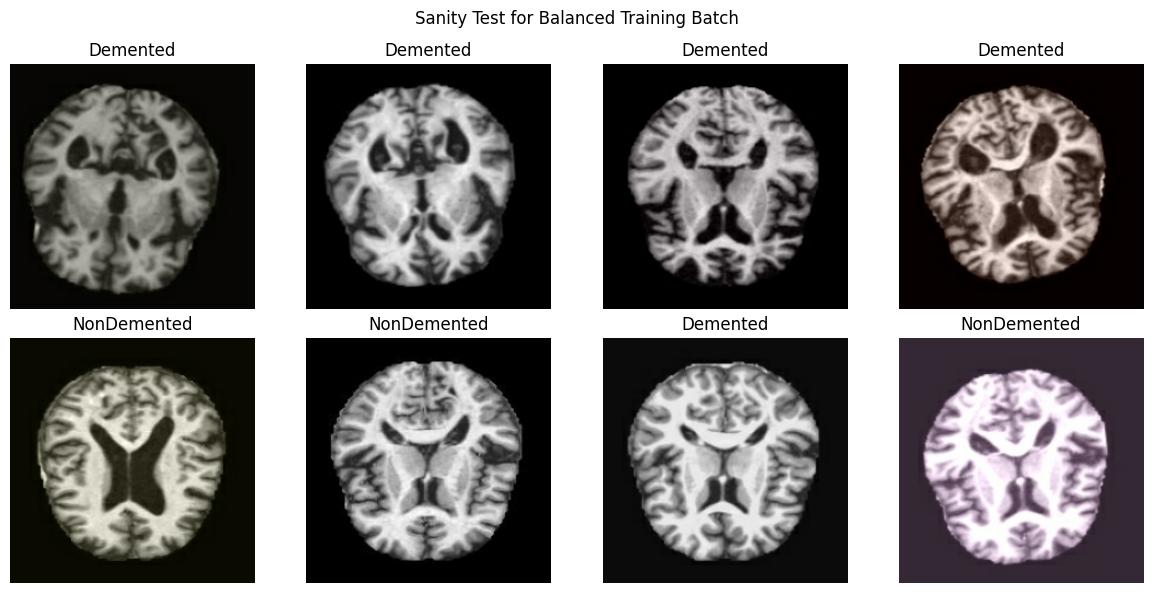

In [10]:
for images, labels in balanced_train_dataset.take(1):
    class_0_count = int(
        tf.reduce_sum(
            tf.cast(labels == 0, tf.int32)
        ).numpy()
    )

    class_1_count = int(
        tf.reduce_sum(
            tf.cast(labels == 1, tf.int32)
        ).numpy()
    )

    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel range:", images.numpy().min(), "to", images.numpy().max())
    print("NonDemented in batch:", class_0_count)
    print("Demented in batch:", class_1_count)

    plt.figure(figsize=(12, 6))

    for index in range(8):
        plt.subplot(2, 4, index + 1)
        plt.imshow(
            tf.cast(images[index], tf.uint8)
        )

        class_name = (
            "Demented"
            if labels[index].numpy() == 1
            else "NonDemented"
        )

        plt.title(class_name)
        plt.axis("off")

    plt.suptitle(
        "Sanity Test for Balanced Training Batch"
    )
    plt.tight_layout()
    plt.show()

In [11]:
MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 0.0001

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)
print("Early-stopping patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Steps per epoch:", STEPS_PER_EPOCH)

print("Preprocessing: Original images")
print("Data augmentation: Disabled")
print("Dropout rate: Disabled")
print("Balanced batches: Enabled")
print("Class weights: Disabled")

Image size: (224, 224)
Batch size: 32
Maximum epochs: 30
Early-stopping patience: 5
Learning rate: 0.0001
Steps per epoch: 963
Preprocessing: Original images
Data augmentation: Disabled
Dropout rate: Disabled
Balanced batches: Enabled
Class weights: Disabled


In [12]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))

x = tf.keras.applications.resnet50.preprocess_input(inputs)

base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Dropout intentionally removed
outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="ResNet50_Balanced_NoDropout"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Total parameters:", model.count_params())
print(
    "Trainable parameters:",
    sum(tf.keras.backend.count_params(w)
        for w in model.trainable_weights)
)
print("ResNet50 frozen:", not base_model.trainable)
print("Dropout enabled: False")

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Total parameters: 23589761
Trainable parameters: 2049
ResNet50 frozen: True
Dropout enabled: False


Model: "ResNet50_Balanced_NoDropout"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/resnet50_balanced_no_dropout_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks created.")

Callbacks created.


In [14]:
history = model.fit(
    balanced_train_dataset,
    validation_data=validation_dataset,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
  3/963 ━━━━━━━━━━━━━━━━━━━━ 46s 48ms/step - accuracy: 0.5000 - loss: 0.8779   

I0000 00:00:1789369060.715856     171 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


962/963 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6433 - loss: 0.6254
Epoch 1: val_loss improved from None to 0.48726, saving model to /kaggle/working/resnet50_balanced_no_dropout_best.keras

Epoch 1: finished saving model to /kaggle/working/resnet50_balanced_no_dropout_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 84s 75ms/step - accuracy: 0.7173 - loss: 0.5575 - val_accuracy: 0.7753 - val_loss: 0.4873 - learning_rate: 1.0000e-04
Epoch 2/30
962/963 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7754 - loss: 0.4771
Epoch 2: val_loss improved from 0.48726 to 0.46658, saving model to /kaggle/working/resnet50_balanced_no_dropout_best.keras

Epoch 2: finished saving model to /kaggle/working/resnet50_balanced_no_dropout_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 56s 59ms/step - accuracy: 0.7742 - loss: 0.4730 - val_accuracy: 0.7780 - val_loss: 0.4666 - learning_rate: 1.0000e-04
Epoch 3/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7776 - loss: 0.4590
Epoch 3: val_loss improved fr

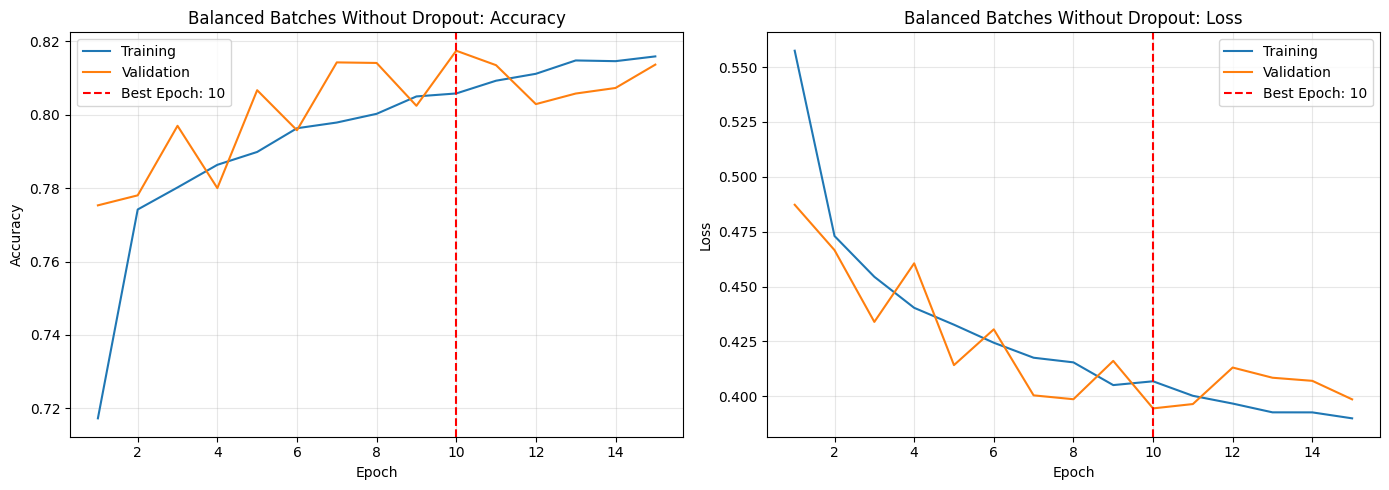

In [15]:
best_epoch = np.argmin(history.history["val_loss"]) + 1
epochs = range(1, len(history.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history.history["accuracy"], label="Training")
axes[0].plot(epochs, history.history["val_accuracy"], label="Validation")
axes[0].axvline(best_epoch, color="red", linestyle="--",
                label=f"Best Epoch: {best_epoch}")
axes[0].set_title("Balanced Batches Without Dropout: Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history.history["loss"], label="Training")
axes[1].plot(epochs, history.history["val_loss"], label="Validation")
axes[1].axvline(best_epoch, color="red", linestyle="--",
                label=f"Best Epoch: {best_epoch}")
axes[1].set_title("Balanced Batches Without Dropout: Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
best_model = tf.keras.models.load_model(
    "/kaggle/working/resnet50_balanced_no_dropout_best.keras"
)

print("Best no-dropout model loaded from epoch:", best_epoch)

Best no-dropout model loaded from epoch: 10


In [17]:
test_loss, test_accuracy = best_model.evaluate(
    test_dataset,
    verbose=1
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

207/207 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - accuracy: 0.8141 - loss: 0.4008
Test Loss: 0.4008
Test Accuracy: 0.8141


In [18]:
test_probabilities = best_model.predict(
    test_dataset,
    verbose=1
).ravel()

test_predictions = (test_probabilities >= 0.5).astype(int)
true_labels = test_df["label"].to_numpy()

print("Test images:", len(true_labels))
print("Probabilities:", len(test_probabilities))
print("Predictions:", len(test_predictions))
print("First probabilities:", np.round(test_probabilities[:10], 4))
print("First predictions:", test_predictions[:10])

207/207 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step
Test images: 6600
Probabilities: 6600
Predictions: 6600
First probabilities: [0.9012 0.8243 0.7426 0.6626 0.9218 0.9141 0.8604 0.5113 0.9784 0.9205]
First predictions: [1 1 1 1 1 1 1 1 1 1]


In [19]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix
)

tn, fp, fn, tp = confusion_matrix(
    true_labels, test_predictions
).ravel()

specificity = tn / (tn + fp)

print("Test Loss:", round(test_loss, 4))
print("Accuracy:", round(accuracy_score(true_labels, test_predictions), 4))
print("Balanced Accuracy:", round(
    balanced_accuracy_score(true_labels, test_predictions), 4
))
print("Precision:", round(
    precision_score(true_labels, test_predictions), 4
))
print("Recall/Sensitivity:", round(
    recall_score(true_labels, test_predictions), 4
))
print("Specificity:", round(specificity, 4))
print("F1-score:", round(
    f1_score(true_labels, test_predictions), 4
))
print("ROC-AUC:", round(
    roc_auc_score(true_labels, test_probabilities), 4
))
print("PR-AUC:", round(
    average_precision_score(true_labels, test_probabilities), 4
))

Test Loss: 0.4008
Accuracy: 0.8141
Balanced Accuracy: 0.8024
Precision: 0.8997
Recall/Sensitivity: 0.8303
Specificity: 0.7745
F1-score: 0.8637
ROC-AUC: 0.8922
PR-AUC: 0.9519


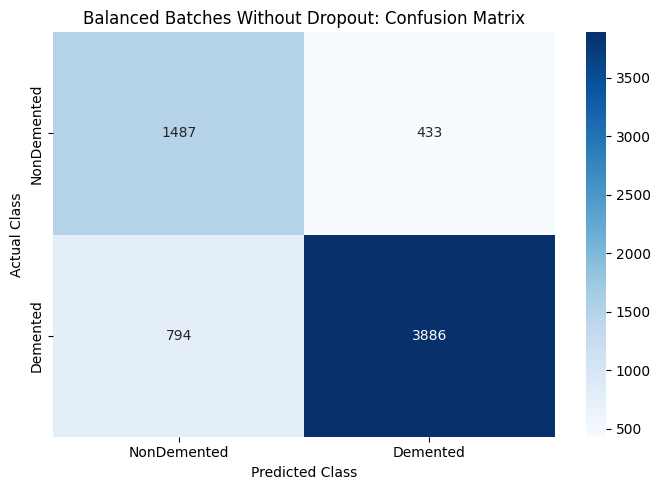

In [20]:
cm = confusion_matrix(true_labels, test_predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NonDemented", "Demented"],
    yticklabels=["NonDemented", "Demented"]
)

plt.title("Balanced Batches Without Dropout: Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        test_predictions,
        target_names=["NonDemented", "Demented"],
        digits=4
    )
)

              precision    recall  f1-score   support

 NonDemented     0.6519    0.7745    0.7079      1920
    Demented     0.8997    0.8303    0.8637      4680

    accuracy                         0.8141      6600
   macro avg     0.7758    0.8024    0.7858      6600
weighted avg     0.8276    0.8141    0.8183      6600



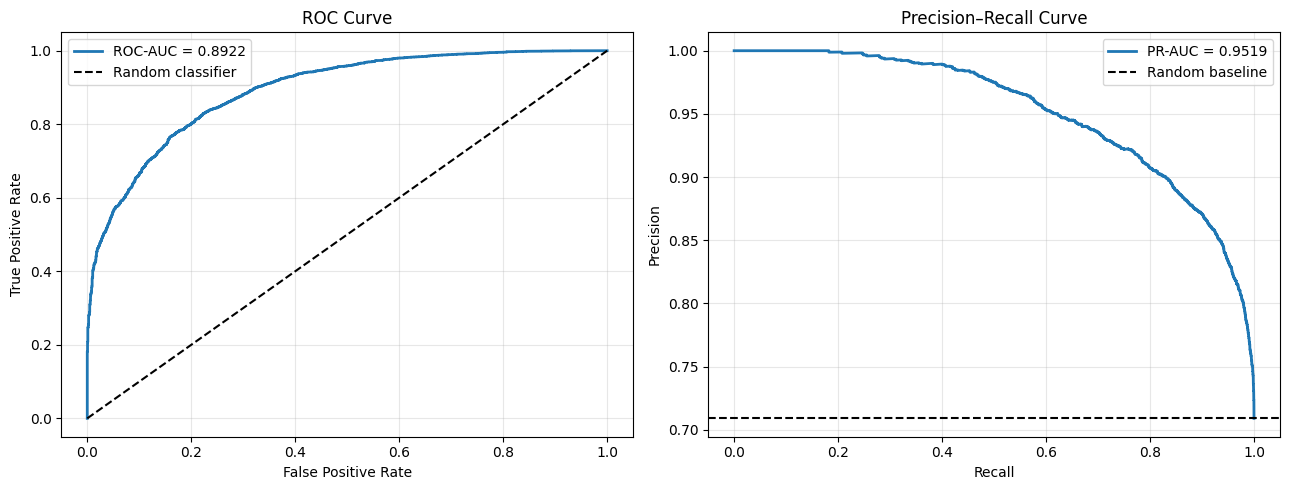

In [22]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(true_labels, test_probabilities)
pr_precision, pr_recall, _ = precision_recall_curve(
    true_labels, test_probabilities
)

roc_auc = roc_auc_score(true_labels, test_probabilities)
pr_auc = average_precision_score(true_labels, test_probabilities)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, linewidth=2,
             label=f"ROC-AUC = {roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", label="Random classifier")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(pr_recall, pr_precision, linewidth=2,
             label=f"PR-AUC = {pr_auc:.4f}")
axes[1].axhline(
    true_labels.mean(),
    color="black",
    linestyle="--",
    label="Random baseline"
)
axes[1].set_title("Precision–Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

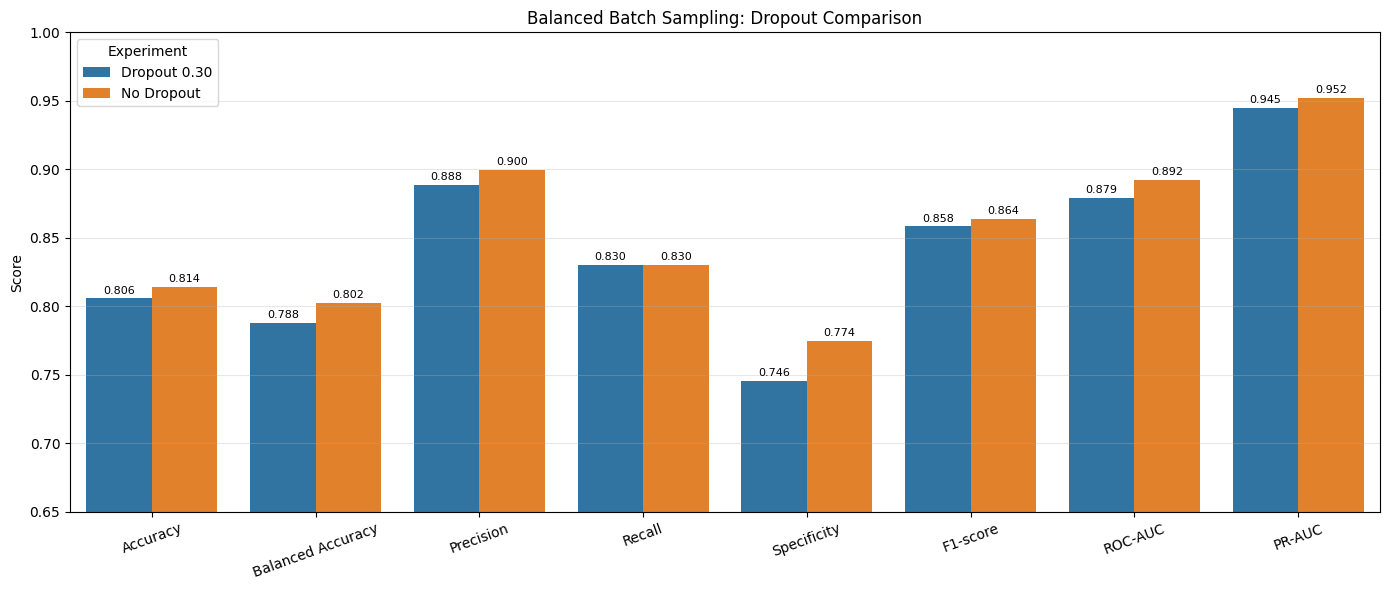

In [23]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy", "Balanced Accuracy", "Precision",
        "Recall", "Specificity", "F1-score",
        "ROC-AUC", "PR-AUC"
    ],
    "Dropout 0.30": [
        0.8058, 0.7881, 0.8884, 0.8303,
        0.7458, 0.8584, 0.8791, 0.9450
    ],
    "No Dropout": [
        0.8141, 0.8024, 0.8997, 0.8303,
        0.7745, 0.8637, 0.8922, 0.9519
    ]
})

plot_data = comparison.melt(
    id_vars="Metric",
    var_name="Experiment",
    value_name="Score"
)

plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=plot_data,
    x="Metric",
    y="Score",
    hue="Experiment"
)

plt.ylim(0.65, 1.0)
plt.title("Balanced Batch Sampling: Dropout Comparison")
plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8)

plt.tight_layout()
plt.show()

In [24]:
results = pd.DataFrame([{
    "Experiment": "ResNet50 Balanced Batches No Dropout",
    "Test Loss": test_loss,
    "Accuracy": accuracy_score(true_labels, test_predictions),
    "Balanced Accuracy": balanced_accuracy_score(
        true_labels, test_predictions
    ),
    "Precision": precision_score(true_labels, test_predictions),
    "Recall": recall_score(true_labels, test_predictions),
    "Specificity": specificity,
    "F1-score": f1_score(true_labels, test_predictions),
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}])

results.to_csv(
    "/kaggle/working/resnet50_balanced_no_dropout_results.csv",
    index=False
)

pd.DataFrame(history.history).to_csv(
    "/kaggle/working/resnet50_balanced_no_dropout_history.csv",
    index=False
)

prediction_results = test_df.copy()
prediction_results["probability"] = test_probabilities
prediction_results["prediction"] = test_predictions
prediction_results.to_csv(
    "/kaggle/working/resnet50_balanced_no_dropout_predictions.csv",
    index=False
)

comparison.to_csv(
    "/kaggle/working/balanced_dropout_comparison.csv",
    index=False
)

display(results)
print("All no-dropout experiment files saved.")

,Experiment,Test Loss,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,PR-AUC
0,ResNet50 Balanced Batches No Dropout,0.400815,0.814091,0.802411,0.899745,0.830342,0.774479,0.863652,0.892216,0.951927


All no-dropout experiment files saved.
